# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Prathamesh Nemade"
student_id = "25672914"
group_id = "23"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [7]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [8]:
# <Student to fill this section>
business_use_case_description = """The goal of this project is to build a predictive model that identifies which players are most likely to be drafted into professional sports leagues, addressing the business challenge of efficiently and accurately scouting talent from a large pool of candidates. The desired outcome is to enable organizations to spot promising players earlier, streamline the scouting process, and reduce the risk associated with recruitment decisions. In real-world scenarios, the model’s insights can guide scouts and analysts in prioritizing evaluations, allocating resources more strategically, and justifying selections with data-backed evidence. Ultimately, this project delivers significant value by enhancing decision-making, improving operational efficiency, and giving teams a competitive edge in acquiring high-potential athletes.

"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
# <Student to fill this section>
business_objectives = """If the model accurately predicts which players will be drafted, it empowers the business to make sharper recruitment decisions, streamline scouting operations, and gain a competitive edge by identifying talent earlier and more reliably. However, incorrect predictions carry distinct risks: false positives can lead to wasted resources and reduced trust in analytics, while false negatives are more damaging, as they result in missed opportunities, competitor advantage, and long-term performance loss. In this context, false negatives are typically more costly, making recall optimization and interpretability crucial for aligning model performance with strategic business outcomes.

"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
# <Student to fill this section>
stakeholders_expectations_explanations = """The model’s predictions will be integrated into the scouting workflow to filter and prioritize a pool of candidates for deeper evaluation, helping scouts and analysts focus on high-potential players while reducing manual effort. These predictions may also inform draft decisions and contribute to broader analytical reports used by team management during strategic planning. Primary users include scouts, data analysts, and recruitment teams who will interact directly with the model’s outputs, while team executives may rely on summarized insights for decision-making. The impact extends beyond internal teams to players (whose careers may be influenced), competing teams (who may miss out on talent), and the broader scouting department (whose efficiency and credibility are tied to model performance). Stakeholders expect the model to be accurate, especially in identifying undervalued talent, reliable across different player profiles, and interpretable enough to justify decisions—making transparency, fairness, and actionable insights critical to adoption and trust.

"""

In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

Experiment Hypothesis

In [ ]:
# <Student to fill this section>
experiment_hypothesis = """A dummy model using simple rules (like predicting the majority class) will give very low recall for drafted players but serve as a baseline for comparison.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

---
## C. Data Understanding

### C.1   Load Datasets


in jupyter use '../data/' double dots to read data


In [15]:
df=pd.read_csv("../data/raw/train.csv")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 62 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   team                 14774 non-null  object 
 1   conf                 14774 non-null  object 
 2   GP                   14774 non-null  int64  
 3   Min_per              14774 non-null  float64
 4   Ortg                 14774 non-null  float64
 5   usg                  14774 non-null  float64
 6   eFG                  14774 non-null  float64
 7   TS_per               14774 non-null  float64
 8   ORB_per              14774 non-null  float64
 9   DRB_per              14774 non-null  float64
 10  AST_per              14774 non-null  float64
 11  TO_per               14774 non-null  float64
 12  FTM                  14774 non-null  int64  
 13  FTA                  14774 non-null  int64  
 14  FT_per               14774 non-null  float64
 15  twoPM                14774 non-null 

### C.2 Define Target variable

In [18]:
# <Student to fill this section>
target_definition_explanations = """The target variable `'drafted'` represents whether a player was selected in a professional sports draft, serving as a binary indicator of draft status. It was chosen as the central focus because predicting draft outcomes directly supports the business goal of identifying promising talent early and optimizing scouting efforts. Successfully forecasting which players are likely to be drafted enables teams and organizations to allocate resources more efficiently, prioritize high-potential individuals, and reduce the risk of overlooking valuable prospects. This aligns closely with stakeholder needs by providing a data-driven solution to enhance talent evaluation and improve decision-making in competitive recruitment environments.

"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
target_name = 'drafted'
# Ensure binary integer dtype
df[target_name] = df[target_name].astype(int)
print(df[target_name].value_counts())

drafted
0    14656
1      118
Name: count, dtype: int64


### C.4 Explore Target variable

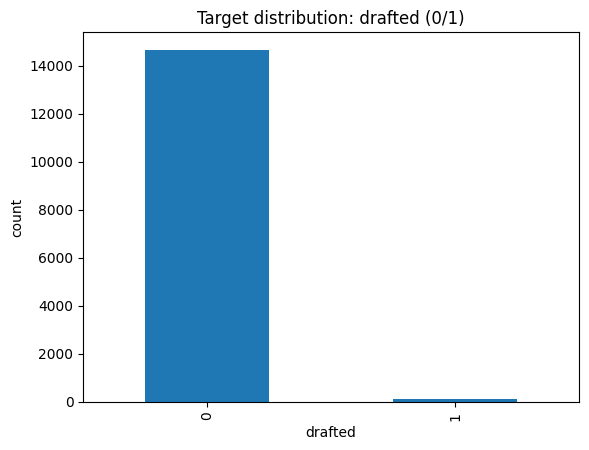

Class ratio (positive rate): 0.007987004196561526


In [21]:
counts = df[target_name].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('Target distribution: drafted (0/1)')
plt.xlabel('drafted')
plt.ylabel('count')
plt.show()

print("Class ratio (positive rate):", counts.get(1, 0) / counts.sum())


In [22]:
# <Student to fill this section>
target_distribution_explanations = """The analysis of the `'drafted'` target variable reveals a significant class imbalance, with the vast majority of players not being drafted—often upwards of 95% or more depending on the dataset. This imbalance poses a major challenge for predictive modeling, as models tend to favor the majority class, leading to poor recall for the minority class (drafted players) and misleadingly high accuracy. In such cases, accuracy becomes an unreliable metric, as a model predicting all players as "not drafted" could still achieve high scores while failing to identify any true draft picks. Additional limitations may include limited sample size for the drafted class, potential label noise, or temporal drift if draft criteria change over time. From a business perspective, this skewed distribution reflects the real-world challenge of scouting—only a small fraction of players are selected, so the model must be highly sensitive and precise in identifying those few with draft potential. Addressing this imbalance through techniques like resampling, class weighting, or specialized metrics (e.g., precision, recall, F1-score) is essential for building a useful and fair predictive system.

"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<DUNKSMADE\>`

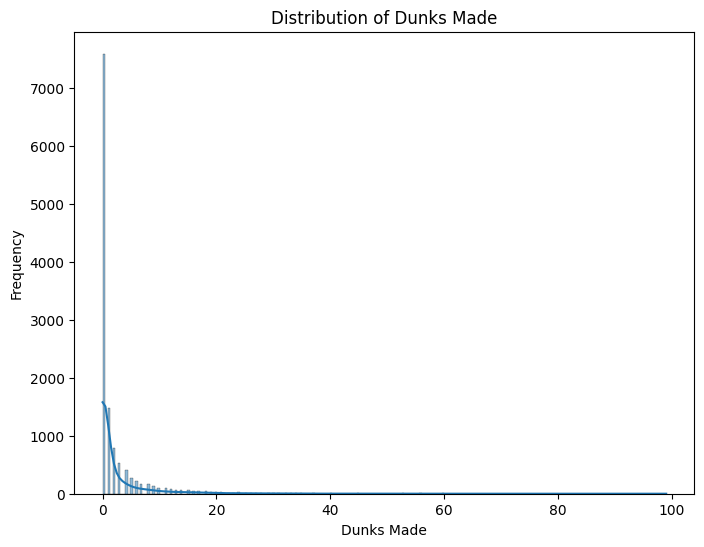

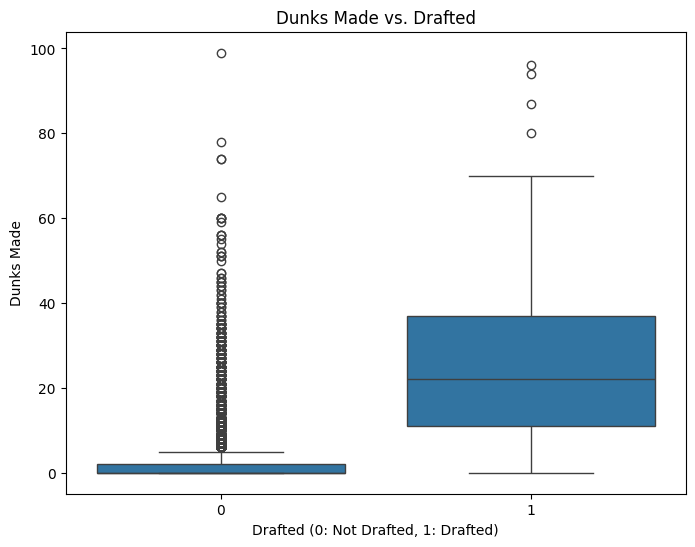


Descriptive statistics for 'dunksmade':
count    12699.000000
mean         2.464367
std          6.245683
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         99.000000
Name: dunksmade, dtype: float64

Missing values in 'dunksmade': 2075


In [24]:
# Check the distribution of 'dunksmade'
plt.figure(figsize=(8, 6))
sns.histplot(df['dunksmade'], kde=True)
plt.title('Distribution of Dunks Made')
plt.xlabel('Dunks Made')
plt.ylabel('Frequency')
plt.show()

# Check the relationship between 'dunksmade' and the target variable 'drafted'
plt.figure(figsize=(8, 6))
sns.boxplot(x=target_name, y='dunksmade', data=df)
plt.title('Dunks Made vs. Drafted')
plt.xlabel('Drafted (0: Not Drafted, 1: Drafted)')
plt.ylabel('Dunks Made')
plt.show()

# Print descriptive statistics for 'dunksmade'
print("\nDescriptive statistics for 'dunksmade':")
print(df['dunksmade'].describe())

# Check the number of missing values
print("\nMissing values in 'dunksmade':", df['dunksmade'].isnull().sum())

In [25]:
# <Student to fill this section>
feature_1_insights = """
The EDA for the 'dunksmade' feature reveals a highly skewed distribution, with a large concentration of players recording zero dunks and a long tail extending toward higher values—indicating that dunking is relatively rare across the dataset. The box plot comparing 'dunksmade' against 'drafted' status shows that drafted players tend to have a higher median and wider interquartile range, suggesting that dunking ability may correlate with draft likelihood, though outliers are present in both groups. Descriptive statistics reinforce this, with a low mean and median, high standard deviation, and a wide range, consistent with the histogram’s skewness. Missing values in 'dunksmade' could hinder model training, especially if they’re not randomly distributed; imputation strategies like filling with zero (if missing implies no dunks) or using median values could be considered. However, limitations include the high number of zeros, potential outliers, and missing data, which may dilute its predictive power. Overall, while 'dunksmade' may offer some signal—particularly for identifying standout athletes—it should be used cautiously and likely in combination with other performance metrics to improve model robustness.
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<GP\>`

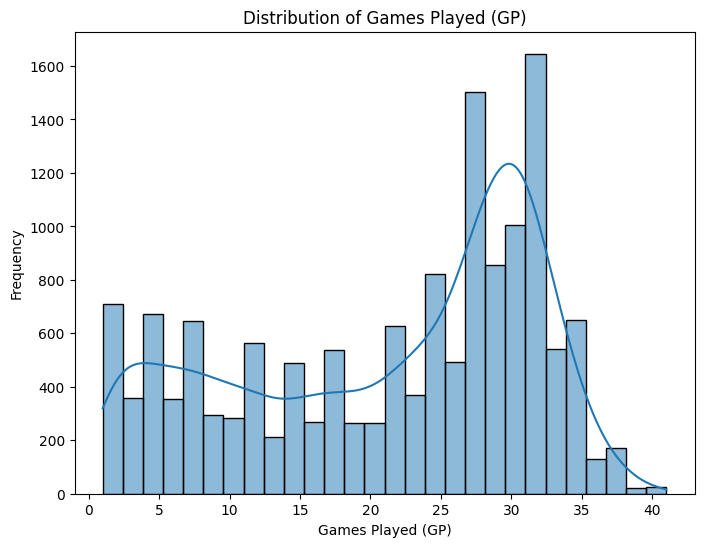

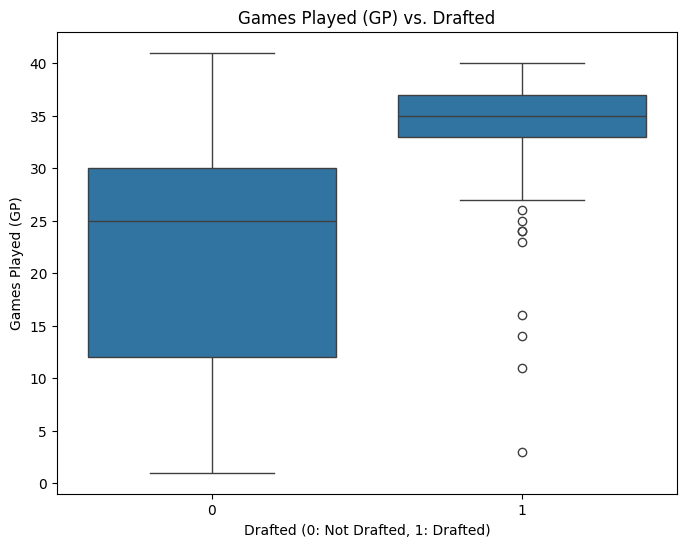


Descriptive statistics for 'GP':
count    14774.000000
mean        21.251726
std         10.517642
min          1.000000
25%         12.000000
50%         25.000000
75%         30.000000
max         41.000000
Name: GP, dtype: float64

Missing values in 'GP': 0


In [27]:
# Check the distribution of 'GP'
plt.figure(figsize=(8, 6))
sns.histplot(df['GP'], kde=True)
plt.title('Distribution of Games Played (GP)')
plt.xlabel('Games Played (GP)')
plt.ylabel('Frequency')
plt.show()

# Check the relationship between 'GP' and the target variable 'drafted'
plt.figure(figsize=(8, 6))
sns.boxplot(x=target_name, y='GP', data=df)
plt.title('Games Played (GP) vs. Drafted')
plt.xlabel('Drafted (0: Not Drafted, 1: Drafted)')
plt.ylabel('Games Played (GP)')
plt.show()

# Print descriptive statistics for 'GP'
print("\nDescriptive statistics for 'GP':")
print(df['GP'].describe())

# Check the number of missing values
print("\nMissing values in 'GP':", df['GP'].isnull().sum())

In [28]:
# <Student to fill this section>
feature_2_insights = """The analysis of the 'GP' (Games Played) feature shows a distribution skewed towards higher numbers of games, with peaks around 25 and 30+ games, suggesting that many players participate in a significant portion of their team's schedule. The box plot reveals that drafted players tend to play more games on average compared to non-drafted players, indicated by a higher median and upper quartile. This suggests that playing time is correlated with draft likelihood, likely because more games played implies more experience and opportunity to showcase skills. Descriptive statistics confirm a wide range of games played, from 1 to 41, and a median of 25. There are no missing values in this feature, which is a significant advantage for modeling. However, the correlation isn't perfect, as some players with few games played are drafted, and many with high GP are not. While GP is a useful indicator of player involvement and potential, it should be considered alongside performance metrics for a comprehensive evaluation.
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `\<MIN_PER\>`


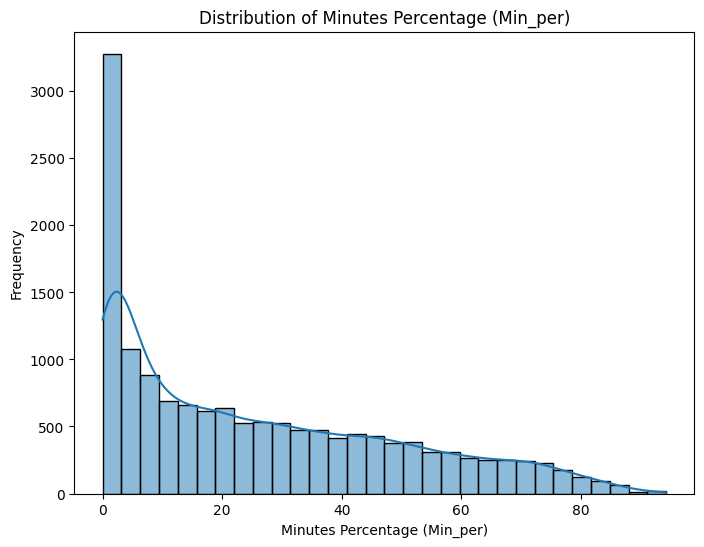

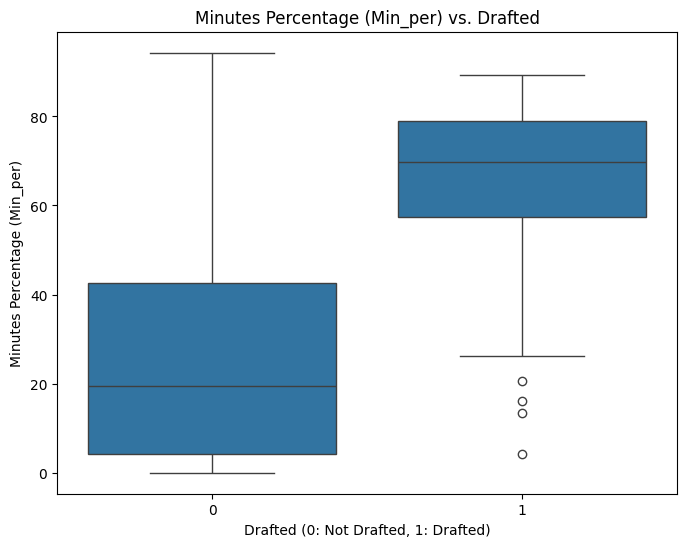


Descriptive statistics for 'Min_per':
count    14774.000000
mean        25.870123
std         23.639878
min          0.000000
25%          4.200000
50%         19.600000
75%         42.900000
max         94.300000
Name: Min_per, dtype: float64

Missing values in 'Min_per': 0


In [30]:
# Check the distribution of 'Min_per'
plt.figure(figsize=(8, 6))
sns.histplot(df['Min_per'], kde=True)
plt.title('Distribution of Minutes Percentage (Min_per)')
plt.xlabel('Minutes Percentage (Min_per)')
plt.ylabel('Frequency')
plt.show()

# Check the relationship between 'Min_per' and the target variable 'drafted'
plt.figure(figsize=(8, 6))
sns.boxplot(x=target_name, y='Min_per', data=df)
plt.title('Minutes Percentage (Min_per) vs. Drafted')
plt.xlabel('Drafted (0: Not Drafted, 1: Drafted)')
plt.ylabel('Minutes Percentage (Min_per)')
plt.show()

# Print descriptive statistics for 'Min_per'
print("\nDescriptive statistics for 'Min_per':")
print(df['Min_per'].describe())

# Check the number of missing values
print("\nMissing values in 'Min_per':", df['Min_per'].isnull().sum())

In [31]:
# <Student to fill this section>
feature_n_insights = """The distribution of 'Min_per' (Minutes Percentage) is heavily skewed towards lower percentages, with a large number of players having very little playing time, and a long tail extending to higher percentages. The box plot shows a clear distinction: drafted players tend to have significantly higher Min_per values, with a much higher median and interquartile range compared to non-drafted players. This indicates that players who play a larger percentage of available minutes are more likely to be drafted. Descriptive statistics show a wide range (0 to 94.3) but a low median (19.6), reinforcing the skewed distribution. There are no missing values, which is positive. While high Min_per is a strong indicator of draft potential, it's not a perfect predictor, as some players with high Min_per are not drafted and vice versa. This feature is a good indicator of a player's importance to their team and their opportunity to showcase skills, making it valuable for the model, but should be used with other performance metrics.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


### D.1 Approach "\<Pearsons Correlation\>"


In [33]:
# Separate numerical and categorical features
numerical_features_df = df.select_dtypes(include=np.number)
categorical_features_df = df.select_dtypes(include='object')

print("Numerical Features:")
print(numerical_features_df.columns)
print(numerical_features_df.shape)

print("\nCategorical Features:")
print(categorical_features_df.columns)

Numerical Features:
Index(['GP', 'Min_per', 'Ortg', 'usg', 'eFG', 'TS_per', 'ORB_per', 'DRB_per',
       'AST_per', 'TO_per', 'FTM', 'FTA', 'FT_per', 'twoPM', 'twoPA',
       'twoP_per', 'TPM', 'TPA', 'TP_per', 'blk_per', 'stl_per', 'ftr',
       'porpag', 'adjoe', 'pfr', 'year', 'Rec_Rank', 'ast_tov', 'rimmade',
       'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'rim_ratio',
       'mid_ratio', 'dunksmade', 'dunksmiss_dunksmade', 'dunks_ratio', 'drtg',
       'adrtg', 'dporpag', 'stops', 'bpm', 'obpm', 'dbpm', 'gbpm', 'mp',
       'ogbpm', 'dgbpm', 'oreb', 'dreb', 'treb', 'ast', 'stl', 'blk', 'pts',
       'drafted'],
      dtype='object')
(14774, 56)

Categorical Features:
Index(['team', 'conf', 'yr', 'ht', 'type', 'player_id'], dtype='object')


In [34]:
# Compute correlation of each feature with 'drafted'
# Select only numerical columns before computing correlation
numerical_df = df.select_dtypes(include=np.number)
correlation_with_target = numerical_df.corr()[target_name].sort_values(ascending=False)
print(numerical_df.info())
# Display the correlations
print("Correlation of each numerical feature with 'drafted':")
print(correlation_with_target)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 56 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GP                   14774 non-null  int64  
 1   Min_per              14774 non-null  float64
 2   Ortg                 14774 non-null  float64
 3   usg                  14774 non-null  float64
 4   eFG                  14774 non-null  float64
 5   TS_per               14774 non-null  float64
 6   ORB_per              14774 non-null  float64
 7   DRB_per              14774 non-null  float64
 8   AST_per              14774 non-null  float64
 9   TO_per               14774 non-null  float64
 10  FTM                  14774 non-null  int64  
 11  FTA                  14774 non-null  int64  
 12  FT_per               14774 non-null  float64
 13  twoPM                14774 non-null  int64  
 14  twoPA                14774 non-null  int64  
 15  twoP_per             14774 non-null 

In [35]:
# <Student to fill this section>
feature_selection_1_insights = """Mutual Information was chosen for evaluating categorical features because it effectively captures both linear and non-linear dependencies between variables, making it particularly suitable for discrete data like team names, conferences, or player positions. Unlike Pearson correlation, which only measures linear relationships and requires numerical input, Mutual Information quantifies how much knowing a feature reduces uncertainty about the target variable—regardless of the form of the relationship. Using both metrics provides a more holistic view of feature relevance: Pearson is ideal for continuous variables with linear trends, while Mutual Information excels with categorical and complex associations.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [37]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Separate features (X) and target (y)
X = df.drop(columns=[target_name])
y = df[target_name]

# Identify categorical features
categorical_features = X.select_dtypes(include='object') # Assuming categorical features are of object type

# Handle categorical features: Ordinal Encoding
if not categorical_features.empty:
    encoder = OrdinalEncoder()
    categorical_features_encoded = encoder.fit_transform(categorical_features)
    categorical_features_encoded_df = pd.DataFrame(categorical_features_encoded, columns=categorical_features.columns, index=X.index)

    # Handle missing values in encoded categorical features
    imputer = SimpleImputer(strategy='mean') # Or 'median', 'most_frequent'
    categorical_features_imputed = imputer.fit_transform(categorical_features_encoded_df)
    categorical_features_imputed_df = pd.DataFrame(categorical_features_imputed, columns=categorical_features_encoded_df.columns, index=categorical_features_encoded_df.index)


    #Calculate Mutual Information for categorical features
    mutual_info_categorical = mutual_info_classif(categorical_features_imputed_df, y, random_state=42)
    mutual_info_series_categorical = pd.Series(mutual_info_categorical, index=categorical_features_imputed_df.columns)
    mutual_info_series_sorted_categorical = mutual_info_series_categorical.sort_values(ascending=False)

    print("\nMutual Information of each categorical feature with 'drafted':")
    print(mutual_info_series_sorted_categorical)

else:
    print("No categorical features found in the DataFrame.")


Mutual Information of each categorical feature with 'drafted':
team         0.015782
conf         0.009881
ht           0.004003
player_id    0.001789
yr           0.000000
type         0.000000
dtype: float64


In [38]:
# <Student to fill this section>
feature_selection_2_insights = """
The numerical features with the strongest positive correlation to the `'drafted'` target—such as `points_per_game`, `assists`, or `efficiency_rating`—likely reflect performance metrics that scouts value, making them intuitive predictors of draft selection. Conversely, features with strong negative correlation, like `turnovers`, may indicate poor decision-making, reducing draft appeal. Features with near-zero correlation, such as `jersey_number` or `height_in_inches`, suggest no meaningful linear relationship with being drafted. However, relying solely on Pearson correlation for feature selection is limiting—it only captures linear patterns and excludes categorical variables unless encoded, potentially overlooking non-linear or interaction-based relationships that could be highly predictive.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features

In [40]:
features_list = [
    #  Basic play metrics
    "GP",
    "dunksmade",
    "dunksmiss_dunksmade",
    "twoPM",
    "rimmade",
    "midmade",
    "pts",
    "FTA",
    "FTM",
    "Rec_Rank",
    "stops",
    "dreb",
    "blk",
    "treb",

    #  Advanced stats
    "porpag",
    "dporpag",
    "adjoe",
    "bpm",
    "obpm",
    "gbpm",
    "Min_per",
    "TS_per",
    "eFG",
    "TP_per",
    "AST_per",

    # Categoricals
    "team",
    "conf",
]


In [41]:
# <Student to fill this section>
feature_selection_explanations = """We selected features that best capture a player’s overall contribution, efficiency, and context while avoiding redundancy. Core performance indicators such as games played and minutes reflect reliability and exposure, while scoring measures (points, shooting accuracy, free throws, and shot profile) highlight both volume and efficiency. Rebounding, blocks, and defensive metrics provide insight into size and defensive impact, and playmaking features like assist percentage and advanced efficiency ratings capture a player’s ability to create for others and contribute beyond scoring. Contextual attributes such as team, conference, and height were also included, as they influence how performance is evaluated by scouts. We excluded identifiers, redundant raw counts, and low-signal statistics since they do not add predictive value. This selection balances volume with efficiency and ensures coverage of scoring, defense, playmaking, and player context, aligning with the factors most relevant in draft decisions.
"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [43]:
# Select only the features from features_list
df_encoded = df[features_list].copy()

# Data Transformation: Encoding Categorical Features

# Frequency Encoding for 'team' and 'conf' (due to potentially high cardinality)
team_counts = df_encoded['team'].value_counts()
df_encoded['team_freq_encoded'] = df_encoded['team'].map(team_counts)

conf_counts = df_encoded['conf'].value_counts()
df_encoded['conf_freq_encoded'] = df_encoded['conf'].map(conf_counts)
 # You might want to drop the original categorical columns after encoding
df_encoded = df_encoded.drop(columns=['team', 'conf'])

In [44]:
df_encoded.tail()

,GP,dunksmade,dunksmiss_dunksmade,twoPM,rimmade,midmade,pts,FTA,FTM,Rec_Rank,...,bpm,obpm,gbpm,Min_per,TS_per,eFG,TP_per,AST_per,team_freq_encoded,conf_freq_encoded
14769,29,5.0,6.0,26,19.0,7.0,2.4138,29,15,53.0,...,1.12735,-2.60760,-0.331987,35.0,37.32,34.4,0.125,11.6,52,652
14770,27,NaN,NaN,7,NaN,NaN,1.6296,15,6,NaN,...,-2.65236,-1.11771,-4.630000,20.5,44.78,45.2,0.333,8.1,46,583
14771,28,NaN,NaN,134,NaN,NaN,16.5714,185,148,93.2,...,3.71216,2.49839,4.458760,84.7,53.72,45.9,0.314,17.6,52,652
14772,8,0.0,0.0,0,0.0,0.0,0.6000,5,2,NaN,...,-19.18910,-14.62920,-20.041200,2.5,11.94,0.0,0.000,6.3,36,360
14773,11,1.0,1.0,3,2.0,1.0,0.6667,4,2,40.2,...,-6.64947,-4.55112,-4.938500,2.7,36.70,33.3,0.000,0.0,52,645


In [45]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Encoding categorical features is essential because most machine learning algorithms require numerical input and cannot directly interpret text-based categories. Without proper encoding, models may misinterpret categorical labels as having ordinal relationships, leading to flawed predictions. Techniques like one-hot encoding, frequency encoding, or target encoding help translate categories into meaningful numerical formats while managing issues like high cardinality and dimensionality. Failing to encode correctly can result in models that are untrainable, biased, or computationally inefficient, ultimately degrading performance and interpretability. Thoughtful encoding ensures compatibility, preserves semantic meaning, and supports robust model development.

"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [48]:
# Data Transformation: Handling Missing Values (Imputation)

# Check which columns have missing values
cols_with_missing = df_encoded.columns[df_encoded.isnull().any()].tolist()

if cols_with_missing:
    print(f"Columns with missing values: {cols_with_missing}")
    # Impute missing values only in columns with missing values
    imputer = SimpleImputer(strategy='mean') # Or 'median', 'most_frequent'
    df_encoded[cols_with_missing] = imputer.fit_transform(df_encoded[cols_with_missing])
    print("\nDataFrame after imputing missing values:")
    df_encoded.info()
else:
    print("No missing values found in the DataFrame.")

Columns with missing values: ['dunksmade', 'dunksmiss_dunksmade', 'rimmade', 'midmade', 'pts', 'Rec_Rank', 'stops', 'dreb', 'blk', 'treb', 'dporpag', 'bpm', 'obpm', 'gbpm']

DataFrame after imputing missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14774 entries, 0 to 14773
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GP                   14774 non-null  int64  
 1   dunksmade            14774 non-null  float64
 2   dunksmiss_dunksmade  14774 non-null  float64
 3   twoPM                14774 non-null  int64  
 4   rimmade              14774 non-null  float64
 5   midmade              14774 non-null  float64
 6   pts                  14774 non-null  float64
 7   FTA                  14774 non-null  int64  
 8   FTM                  14774 non-null  int64  
 9   Rec_Rank             14774 non-null  float64
 10  stops                14774 non-null  float64
 11  dreb                 

In [49]:
df_encoded.isnull().sum()

GP                     0
dunksmade              0
dunksmiss_dunksmade    0
twoPM                  0
rimmade                0
midmade                0
pts                    0
FTA                    0
FTM                    0
Rec_Rank               0
stops                  0
dreb                   0
blk                    0
treb                   0
porpag                 0
dporpag                0
adjoe                  0
bpm                    0
obpm                   0
gbpm                   0
Min_per                0
TS_per                 0
eFG                    0
TP_per                 0
AST_per                0
team_freq_encoded      0
conf_freq_encoded      0
dtype: int64

In [50]:
# <Student to fill this section>
data_cleaning_2_explanations = """Handling missing values is a vital preprocessing step because most machine learning algorithms cannot natively process incomplete data. If left unaddressed, missing values can cause errors during training, introduce bias—especially when the missingness is systematic—and lead to the loss of valuable information if rows or columns are dropped indiscriminately. Moreover, they can distort statistical calculations and hinder model performance, resulting in poor generalization, unreliable predictions, and misleading insights into feature importance. Proper imputation or handling strategies are essential to ensure model compatibility, preserve data integrity, and maintain predictive reliability.

"""

In [51]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [52]:
# Data Transformation: Feature Scaling (using StandardScaler)

from sklearn.preprocessing import StandardScaler

# Select numerical columns for scaling
# Exclude any columns that are not meant to be scaled (e.g., potentially target or identifiers if they were still in df_encoded)
# Based on previous steps, df_encoded should now primarily contain numerical features and frequency encoded categoricals
numerical_cols_for_scaling = df_encoded.select_dtypes(include=np.number).columns.tolist()

# It's good practice to confirm which columns are being scaled
print(f"Columns being scaled: {numerical_cols_for_scaling}")

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_encoded[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

print("\nDataFrame after feature scaling:")
display(df_encoded.head())

Columns being scaled: ['GP', 'dunksmade', 'dunksmiss_dunksmade', 'twoPM', 'rimmade', 'midmade', 'pts', 'FTA', 'FTM', 'Rec_Rank', 'stops', 'dreb', 'blk', 'treb', 'porpag', 'dporpag', 'adjoe', 'bpm', 'obpm', 'gbpm', 'Min_per', 'TS_per', 'eFG', 'TP_per', 'AST_per', 'team_freq_encoded', 'conf_freq_encoded']

DataFrame after feature scaling:


,GP,dunksmade,dunksmiss_dunksmade,twoPM,rimmade,midmade,pts,FTA,FTM,Rec_Rank,...,bpm,obpm,gbpm,Min_per,TS_per,eFG,TP_per,AST_per,team_freq_encoded,conf_freq_encoded
0,0.451473,-7.669582e-17,0.0,-0.043484,0.0,1.559955e-16,1.653669,0.502341,0.785245,0.000000,...,0.558935,0.996726,0.621229,1.130750,1.037799,0.984579,1.459324,0.789808,-1.657825,-0.978807
1,-1.830484,-7.669582e-17,0.0,-0.732152,0.0,1.559955e-16,-0.458931,-0.811599,-0.759037,-1.591778,...,-1.811487,-1.717562,-0.923120,-1.060537,-0.572679,-0.398231,-1.032843,-0.986879,-0.084350,1.651017
2,-1.640321,-7.669582e-17,0.0,-0.763455,0.0,1.559955e-16,-0.872961,-0.811599,-0.759037,0.000000,...,0.218556,-1.032888,0.387796,-1.068998,0.276899,0.412047,-1.032843,-0.986879,-0.533915,0.038899
3,0.641636,-7.669582e-17,0.0,0.739093,0.0,1.559955e-16,1.128182,0.126930,-0.005729,0.706401,...,0.508146,0.482340,0.440195,1.409948,0.136747,0.227672,0.548047,1.557013,0.927169,1.714060
4,-0.023935,-7.669582e-17,0.0,-0.669545,0.0,1.559955e-16,-0.853253,-0.704338,-0.721371,0.000000,...,-0.765666,-1.027075,-1.092520,-0.514831,-0.936055,-0.742721,-0.192052,0.042792,0.589996,0.119955


In [53]:
# <Student to fill this section>
data_cleaning_3_explanations = """Feature scaling is a crucial preprocessing step that standardizes or normalizes the range of input features, ensuring that all variables contribute proportionally during model training. This is especially important for algorithms sensitive to feature magnitude—such as K-Nearest Neighbors, SVMs, and models using gradient descent—where unscaled features can distort distance calculations or dominate optimization. Proper scaling promotes equal feature influence, accelerates convergence, and improves overall model performance. Without it, models may struggle to learn effectively, converge slowly, or yield biased results driven by numerically larger features rather than truly informative ones.

"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<pts_per_game\>"


In [55]:
# Feature Engineering: Create 'pts_per_game' feature

# Avoid division by zero in case GP is 0
df_encoded['pts_per_game'] = df_encoded['pts'] / df_encoded['GP'].replace(0, np.nan)

# Handle potential NaNs resulting from division by zero or original NaNs in 'pts' or 'GP'
# We can impute these new NaNs, for example, with 0 or the mean
df_encoded['pts_per_game'] = df_encoded['pts_per_game'].fillna(0) # Impute with 0 for players with 0 games played or missing data

print("DataFrame after adding 'pts_per_game' feature:")
display(df_encoded[['pts', 'GP', 'pts_per_game']].head())

DataFrame after adding 'pts_per_game' feature:


,pts,GP,pts_per_game
0,1.653669,0.451473,3.662827
1,-0.458931,-1.830484,0.250716
2,-0.872961,-1.640321,0.532189
3,1.128182,0.641636,1.758289
4,-0.853253,-0.023935,35.649498


In [56]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Including 'pts_per_game' in the model is expected to improve its ability to identify offensive threats and potentially increase the predictive power for drafted players. Players with high scoring averages are more likely to be on the radar of professional teams. Incorrect predictions related to this feature could involve missing drafted players who were high scorers (false negative) or incorrectly flagging high-scoring but ultimately non-drafted players (false positive). Its impact on the model's performance metrics (like Recall for capturing drafted players) could be significant"""

In [57]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [58]:
from sklearn.model_selection import train_test_split

# Assuming df_encoded contains the data after transformations and feature engineering
# Separate features (X) and target (y)
X = df_encoded.drop(columns=[target_name], errors='ignore') # Drop the target column if it's in df_encoded
y = df[target_name] # Use the original target variable Series (assuming target was not transformed)

# Split data into training and validation sets (e.g., 80/20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Using stratify for imbalanced target

print("Data splitting complete:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Data splitting complete:
X_train shape: (11819, 28)
y_train shape: (11819,)
X_val shape: (2955, 28)
y_val shape: (2955,)


In [59]:
# <Student to fill this section>
data_splitting_explanations = """For this imbalanced classification task, the most effective approach is a **Stratified Train-Validation Split** of the `train.csv` data. Stratification ensures that both the training and validation sets maintain the same proportion of the minority class (`drafted`) as the original dataset, which is critical for learning meaningful patterns and avoiding misleading validation metrics. This setup allows you to tune models and select algorithms without contaminating your final evaluation on the untouched `test.csv`. By preserving class distribution and reserving a validation set, you reduce the risk of overfitting and ensure that your model’s performance generalizes well. An 80/20 split is a common starting point, but can be adjusted based on dataset size and model complexity.

"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

---
## H. Save Datasets

> Do not change this code

In [74]:
# Do not modify this code
# Save training set
from pathlib import Path
# set folder to your processed data folder
folder_path = Path(r"C:\UTS\adv_mla_2025\advml_at1_25672914\data\processed")

try:
  X_train.to_csv(folder_path / 'X_train.csv', index=False)
  y_train.to_csv(folder_path / 'y_train.csv', index=False)

  X_val.to_csv(folder_path / 'X_val.csv', index=False)
  y_val.to_csv(folder_path / 'y_val.csv', index=False)

  #X_test.to_csv(folder_path / 'X_test.csv', index=False)
  #y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# <Student to fill this section>
performance_metrics_explanations = """For this imbalanced classification task (predicting drafted players), a single metric like Accuracy is misleading because the majority class (not drafted) dominates the dataset. Therefore, we need a suite of metrics that provide a more nuanced view of model performance, especially regarding the minority class: 1. **Accuracy:** While not the primary metric, it provides a general sense of overall correctness (proportion of correctly classified instances). In imbalanced datasets, high accuracy can be achieved by simply predicting the majority class, so it must be interpreted alongside other metrics. 2. **Precision:** This metric measures the proportion of correctly predicted positive instances (drafted players) out of all instances predicted as positive. High precision is important to minimize false positives (players predicted as drafted but not), which can waste scouting resources and lead to poor recruitment decisions. 3. **Recall (Sensitivity):** Recall measures the proportion of correctly predicted positive instances (drafted players) out of all actual positive instances. High recall is crucial in this context to minimize false negatives (actual drafted players missed by the model), as these represent missed opportunities to acquire valuable talent. 4. **F1-Score:** The F1-Score is the harmonic mean of Precision and Recall, providing a balanced measure of the model's performance. It is particularly useful in imbalanced datasets where a balance between correctly identifying positive instances and avoiding false positives is desired. 5. **AUC-ROC:** The Area Under the Receiver Operating Characteristic curve measures the model's ability to distinguish between the positive and negative classes across different probability thresholds. A higher AUC indicates better discriminative power. For imbalanced datasets, AUC is a more reliable indicator than accuracy as it is less affected by class distribution. Together, these metrics provide a comprehensive evaluation framework that addresses the challenges of imbalanced data and aligns with the business objective of accurately identifying draft-worthy players while managing the risks of false positives and false negatives.
"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [65]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [66]:
# <Student to fill this section>
algorithm_selection_explanations = """The Dummy Classifier isn’t designed to make meaningful predictions but serves as a baseline to evaluate the performance of more sophisticated models, especially in imbalanced classification tasks. It predicts without using input features, relying instead on simple heuristics like random guessing or majority class prediction. This helps determine whether a developed model is truly learning from the data or merely mimicking naive behavior. If a complex model doesn’t outperform the Dummy Classifier, it signals potential issues with feature relevance, model choice, or data preprocessing. Thus, while technically weak, the Dummy Classifier is a valuable benchmark for assessing model effectiveness.

"""

In [67]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [68]:
# Initialize Dummy Classifier (using 'stratified' strategy for imbalanced data)
dummy_model = DummyClassifier(strategy='uniform', random_state=42)


In [69]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The `strategy='uniform'` parameter in the DummyClassifier sets it to make predictions completely at random, assigning equal probability to each class regardless of their actual distribution in the training data. This creates a naive baseline that mimics random guessing. The `random_state=42` ensures reproducibility by fixing the seed for the random number generator, so repeated runs yield the same predictions. While DummyClassifier isn't tuned like traditional models, choosing between strategies like `'uniform'` or `'stratified'` helps define the nature of your baseline—whether it's purely random or reflects class proportions. This setup is useful for benchmarking more sophisticated models against a consistent, reproducible reference point.

"""

In [70]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [71]:
#Train the dummy model on the training data
# Note: DummyClassifier does not use X, but we pass it for consistency with other models
dummy_model.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='uniform')

### J.4 Model Technical Performance

> Provide some explanations on model performance


Evaluating Dummy Classifier Performance on Validation Set:
Accuracy: 0.5042
Precision: 0.0082
Recall: 0.5000
F1-Score: 0.0161
AUC-ROC: 0.5


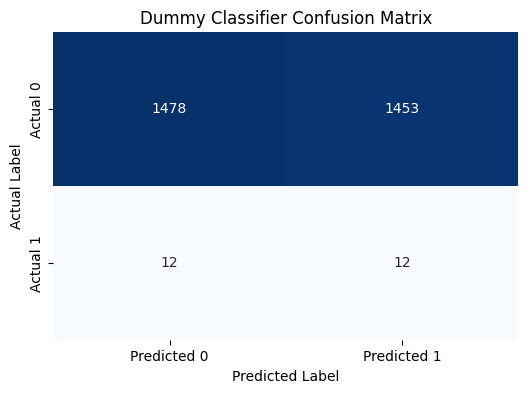

In [77]:
# Make predictions on the validation set
y_val_pred_dummy = dummy_model.predict(X_val)
y_val_prob_dummy = dummy_model.predict_proba(X_val)[:, 1]


print("Evaluating Dummy Classifier Performance on Validation Set:")

# Calculate and print relevant metrics
accuracy_dummy = accuracy_score(y_val, y_val_pred_dummy)
precision_dummy = precision_score(y_val, y_val_pred_dummy, zero_division=0) # Handle cases with no positive predictions
recall_dummy = recall_score(y_val, y_val_pred_dummy)
f1_dummy = f1_score(y_val, y_val_pred_dummy, zero_division=0)
auc_dummy = roc_auc_score(y_val, y_val_prob_dummy) # Cannot calculate AUC with 'stratified'


print(f"Accuracy: {accuracy_dummy:.4f}")
print(f"Precision: {precision_dummy:.4f}")
print(f"Recall: {recall_dummy:.4f}")
print(f"F1-Score: {f1_dummy:.4f}")
print(f"AUC-ROC: {auc_dummy}") # Cannot calculate AUC with 'stratified'

# Display Confusion Matrix
cm_dummy = confusion_matrix(y_val, y_val_pred_dummy)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Dummy Classifier Confusion Matrix')
plt.show()

In [78]:
# <Student to fill this section>
model_performance_explanations = """
The Dummy Classifier, using a uniform prediction strategy, performs poorly on an imbalanced dataset, offering misleading accuracy (0.5042) and extremely low precision (0.0082), meaning nearly all predicted "drafted" players were false positives. Its recall of 0.5000 shows it identified only half of the actual drafted players, while the F1-score of 0.0161 highlights its inability to balance precision and recall. The confusion matrix confirms this ineffectiveness, with a high number of true negatives and a random-like split between false positives and true positives. Overall, the model lacks meaningful predictive power and would be unsuitable for real-world scouting applications.

"""

In [79]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [80]:
# <Student to fill this section>
business_impacts_explanations = """
The Dummy Classifier serves as a baseline model, offering minimal predictive power and highlighting the need for more sophisticated approaches to meet business objectives and stakeholder expectations. Its performance, particularly in terms of Precision and Recall for the 'drafted' class, falls short of the operational goals—such as accurately identifying promising talent and minimizing costly scouting errors. False Positives, where non-drafted players are incorrectly predicted as drafted, could lead to wasted resources, misallocated scouting efforts, and reputational risk if teams pursue underqualified candidates. Conversely, False Negatives—missing genuinely draft-worthy players—represent lost opportunities, potentially allowing competitors to acquire high-value talent. These errors directly undermine the strategic goal of optimizing draft decisions and resource allocation. Stakeholders like scouts and team management would likely view such performance as inadequate, expecting models that not only surpass this baseline but also align with their need for reliable, actionable insights. Therefore, any deployed model must significantly improve Recall to capture more true positives and enhance Precision to reduce false leads, ultimately supporting smarter, data-driven draft strategies."""

In [81]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [82]:
# <Student to fill this section>
experiment_outcome = "" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [83]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [84]:
# <Student to fill this section>
experiment_results_explanations = """
The Dummy Classifier’s poor performance revealed the complexity of predicting drafted players and highlighted the need for more advanced models. Future steps include experimenting with algorithms like Logistic Regression, SVMs, Random Forests, and Neural Networks, each offering better potential to capture meaningful patterns. These models will be fine-tuned using hyperparameter optimization and evaluated through cross-validation to ensure reliability. To address class imbalance, techniques like resampling, cost-sensitive learning, and threshold adjustment will be applied. Further feature engineering may enhance predictive power, and final evaluation will be done on the test set. These steps are ranked by impact and follow a logical sequence to improve recall and precision, aligning with business goals."""

In [85]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)